--- 1. Dataset Loading & Description ---
<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 34.5 KB
None

--- 2. Data Cleaning & Handling Missing Values ---
Remaining Missing Values: 0

--- 3. Exploratory Data Analysis (EDA) ---


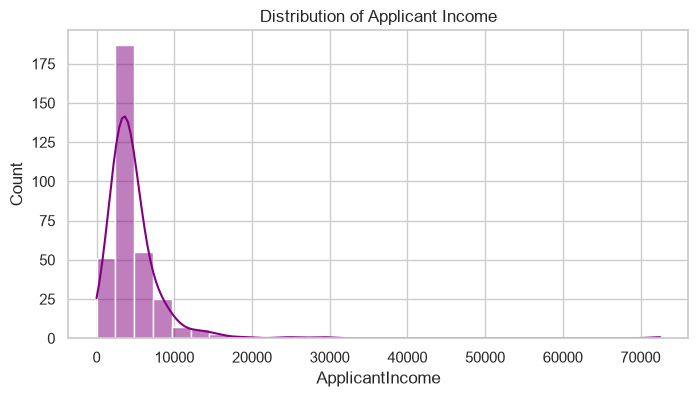


--- 4. Feature Encoding & Data Splitting ---

--- 5. Model Training & Testing ---

--- 6. Evaluation Metrics ---
Accuracy Score: 0.8088

Confusion Matrix:
[[ 1 11]
 [ 2 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.08      0.13        12
           1       0.83      0.96      0.89        56

    accuracy                           0.81        68
   macro avg       0.58      0.52      0.51        68
weighted avg       0.74      0.81      0.76        68



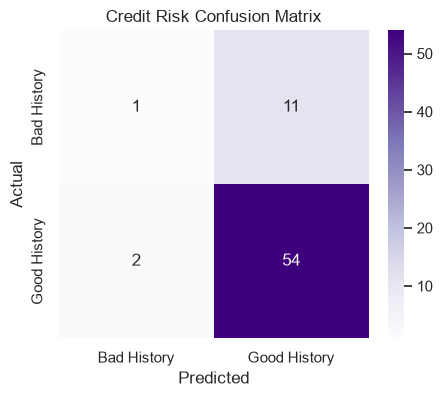

In [17]:
# ==========================================
# TASK 2: CREDIT RISK PREDICTION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("--- 1. Dataset Loading & Description ---")
df_credit = pd.read_csv("test.csv")
print(df_credit.info())

print("\n--- 2. Data Cleaning & Handling Missing Values ---")
# Drop unique identifier
df_credit = df_credit.drop(columns=['Loan_ID'])

# Impute Missing Values
# Categorical -> Mode; Numerical -> Median
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df_credit[col] = df_credit[col].fillna(df_credit[col].mode()[0])

df_credit['LoanAmount'] = df_credit['LoanAmount'].fillna(df_credit['LoanAmount'].median())
df_credit['Loan_Amount_Term'] = df_credit['Loan_Amount_Term'].fillna(df_credit['Loan_Amount_Term'].mode()[0])

# Drop entries where target variable (Credit_History) is missing
df_credit = df_credit.dropna(subset=['Credit_History'])
print(f"Remaining Missing Values: {df_credit.isnull().sum().sum()}")

print("\n--- 3. Exploratory Data Analysis (EDA) ---")
# Distribution of Applicant Income
plt.figure(figsize=(8, 4))
sns.histplot(df_credit['ApplicantIncome'], kde=True, color='purple', bins=30)
plt.title("Distribution of Applicant Income")
plt.show()

print("\n--- 4. Feature Encoding & Data Splitting ---")
# One-Hot Encoding for categorical features
X = df_credit.drop(columns=['Credit_History'])
y = df_credit['Credit_History'].astype(int)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- 5. Model Training & Testing ---")
clf_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_tree.fit(X_train, y_train)
y_pred = clf_tree.predict(X_test)

print("\n--- 6. Evaluation Metrics ---")
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy Score: {acc:.4f}\n")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Bad History', 'Good History'], yticklabels=['Bad History', 'Good History'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Credit Risk Confusion Matrix')
plt.show()